Load Data, check probes from infant dataset

In [2]:
library(limma)
data_dir <- '/home/ethan-xiao/food-allergy-biomarkers/data'

#Reloading necessary data
mVals_189148_shared <- readRDS(file.path(data_dir, 'mVals_189148_shared.rds'))
allergy_status <- readRDS(file.path(data_dir, 'allergy_status.rds'))
batch <- readRDS(file.path(data_dir, 'batch.rds'))
scan_dates <- readRDS(file.path(data_dir, 'scan_dates_189148.rds'))

status_189148 <- allergy_status[batch == 'GSE189148']
design_189148 <- model.matrix(~ status_189148 + factor(scan_dates))
fit_189148 <- eBayes(lmFit(mVals_189148_shared, design_189148))
tt_189148 <- topTable(fit_189148, coef = 2, number = Inf, sort.by = 'none')

tt_189148[c('cg11090352','cg15076659','cg08469540'),
          c('logFC','P.Value','adj.P.Val')]

,logFC,P.Value,adj.P.Val
,<dbl>,<dbl>,<dbl>
cg11090352,0.08242869,0.07682545,0.9999969
cg15076659,0.04219258,0.66980577,0.9999969
cg08469540,-0.37996349,0.05487312,0.9999969


Check ISG15 nearby probes

In [3]:
BiocManager::install("IlluminaHumanMethylationEPICanno.ilm10b4.hg19")
library(minfi)
library(IlluminaHumanMethylationEPICanno.ilm10b4.hg19)
ann <- getAnnotation(IlluminaHumanMethylationEPICanno.ilm10b4.hg19)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.3 (2026-03-11)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'IlluminaHumanMethylationEPICanno.ilm10b4.hg19'”
Old packages: 'bitops', 'DelayedArray', 'lattice', 'Matrix', 'S4Vectors',
  'SparseArray', 'stringi', 'XML'

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs



In [4]:
mVals_114134_shared <- readRDS(file.path(data_dir, 'mVals_114134_shared.rds'))
status_114134 <- allergy_status[batch == 'GSE114134']
fit_114134 <- eBayes(lmFit(mVals_114134_shared, model.matrix(~ status_114134)))
tt_114134 <- topTable(fit_114134, coef = 2, number = Inf, sort.by = 'none')

dim(tt_114134)

[1] 751107      6

In [5]:
saveRDS(tt_114134, file.path(data_dir, 'tt_114134.rds'))
saveRDS(tt_189148, file.path(data_dir, 'tt_189148.rds'))

In [6]:
ann <- getAnnotation(IlluminaHumanMethylationEPICanno.ilm10b4.hg19)
isg15 <- rownames(ann)[grepl('ISG15', ann$UCSC_RefGene_Name)]
isg15 <- intersect(isg15, rownames(tt_189148))

data.frame(
  probe = isg15,
  pos   = ann[isg15, 'pos'],
  island = ann[isg15, 'Relation_to_Island'],
  lfc_infant = tt_114134[isg15, 'logFC'],
  p_infant   = tt_114134[isg15, 'P.Value'],
  lfc_adol   = tt_189148[isg15, 'logFC'],
  p_adol     = tt_189148[isg15, 'P.Value']
)

probe,pos,island,lfc_infant,p_infant,lfc_adol,p_adol
<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
cg21503301,948814,Island,-0.21333937,8.724205e-02,0.173497639,0.00266151
cg20022511,948740,Island,-0.05222767,3.505424e-01,0.075081781,0.28185493
cg22115423,948819,Island,-0.08331560,1.216829e-01,0.113825462,0.20255527
cg08067365,948893,Island,-0.08882691,1.204951e-01,-0.116914446,0.07678694
cg04788999,949850,Island,-0.05365011,3.885802e-01,0.109688496,0.32035220
cg20062691,949392,Island,-0.08367150,2.488450e-01,0.092598988,0.36894681
cg23684711,948879,Island,-0.01089672,7.915002e-01,-0.028815062,0.69245430
cg11211792,949634,Island,-0.06119426,4.036039e-01,0.044092841,0.68305080
cg22182593,947864,N_Shore,0.03273700,5.918388e-01,-0.003626881,0.97505554


Checking DMR

In [7]:
library(bumphunter)
ls()

[1] "allergy_status"      "ann"                 "batch"              
 [4] "data_dir"            "design_189148"       "fit_114134"         
 [7] "fit_189148"          "isg15"               "mVals_114134_shared"
[10] "mVals_189148_shared" "scan_dates"          "status_114134"      
[13] "status_189148"       "tt_114134"           "tt_189148"

In [8]:
chr <- ann[rownames(mVals_114134_shared), 'chr']
pos <- ann[rownames(mVals_114134_shared), 'pos']

sum(is.na(chr))   #should be 0
ord <- order(chr, pos)
cluster <- clusterMaker(chr[ord], pos[ord], maxGap = 500)
length(unique(cluster))

[1] 0

[1] 381976

In [9]:
rm(mVals_189148_shared, fit_114134, fit_189148, tt_189148)
gc()
chr <- ann[rownames(mVals_114134_shared), 'chr']
pos <- ann[rownames(mVals_114134_shared), 'pos']
rm(ann); gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,16940009,904.7,27782892,1483.8,17787650,950.0
Vcells,165877966,1265.6,474693681,3621.7,474665979,3621.5


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,16940649,904.8,27782892,1483.8,17787650,950.0
Vcells,165879138,1265.6,474693681,3621.7,474665979,3621.5


In [10]:
m_ord <- mVals_114134_shared[ord, ]
rm(mVals_114134_shared); gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,16940609,904.8,27782892,1483.8,17787650,950.0
Vcells,165879058,1265.6,474693681,3621.7,474665979,3621.5


In [11]:
design_114134 <- model.matrix(~ status_114134)

chr_ord <- chr[ord]
pos_ord <- pos[ord]

set.seed(42)
bumps <- bumphunter(m_ord, design_114134, chr = chr_ord, pos = pos_ord,
                    cluster = cluster, coef = 2,
                    cutoff = 0.15, B = 50, type = "M")

saveRDS(bumps, file.path(data_dir, 'bumphunter_114134.rds'))
dim(bumps$table)

[bumphunterEngine] Using a single core (backend: doSEQ, version: 1.5.2).

[bumphunterEngine] Computing coefficients.

[bumphunterEngine] Performing 50 permutations.

[bumphunterEngine] Computing marginal permutation p-values.

[bumphunterEngine] cutoff: 0.15

[bumphunterEngine] Finding regions.

[bumphunterEngine] Found 38638 bumps.

[bumphunterEngine] Computing regions for each permutation.

Loading required package: rngtools

[bumphunterEngine] Estimating p-values and FWER.



[1] 38638    14

In [12]:
#Checking significant (how many regions make it past FWER correction)
sum(bumps$table$fwer < 0.05, na.rm = TRUE)
sum(bumps$table$p.valueArea < 0.05, na.rm = TRUE)

[1] 0

[1] 2489

In [13]:
subset(bumps$table, chr == 'chr1' & start < 950000 & end > 948000) #Searching manually for ISG15 bc its fwer is too big

,chr,start,end,value,area,cluster,indexStart,indexEnd,L,clusterL,p.value,fwer,p.valueArea,fwerArea
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
16453,chr1,948625,948627,-0.2232425,0.4464850,93,281,282,2,12,0.01749817,1,0.02752862,1
16454,chr1,948814,948814,-0.2133394,0.2133394,93,284,284,1,12,0.22647119,1,0.25320343,1


In [14]:
bumps$table[1:10, c('chr','start','end','value','area','L','p.value','fwer')]

,chr,start,end,value,area,L,p.value,fwer
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
12634,chr5,135414858,135416613,0.4105861,7.390550,18,2.979933e-06,0.08
3412,chr12,739953,740338,0.6859428,3.429714,5,1.638963e-05,0.34
8249,chr2,30669597,30669863,0.7692717,3.077087,4,2.011455e-05,0.40
37973,chr8,144660395,144660772,-0.5151121,3.605785,7,3.799415e-05,0.70
23639,chr15,22833172,22833400,-0.4498230,3.148761,7,7.077341e-05,0.88
30763,chr22,48314374,48314866,-0.7588537,1.517707,2,7.822324e-05,0.88
32718,chr4,116877727,116877727,-1.1795189,1.179519,1,6.928345e-05,0.88
37828,chr8,125462978,125463310,-0.3911337,2.737936,7,1.236672e-04,0.98
37158,chr8,11666017,11666810,-0.3315998,2.652798,8,1.564465e-04,0.98


Check Relevant Probes

In [17]:
#reload annotation bc it was deliberately removed earlier to free memory
library(IlluminaHumanMethylationEPICanno.ilm10b4.hg19)
ann <- getAnnotation(IlluminaHumanMethylationEPICanno.ilm10b4.hg19)

In [18]:
top_probes <- rownames(ann)[ann$chr == 'chr5' &
                            ann$pos >= 135414858 &
                            ann$pos <= 135416613]
length(top_probes)
unique(ann[top_probes, 'UCSC_RefGene_Name'])

ann_top <- ann[chr == 'chr5' & pos >= 135414858 & pos <= 135416613, ]
unique(ann_top$UCSC_RefGene_Name)

[1] 18

[1] ""       "MIR886"

[1] "HN1;HN1;HN1"    "RAB32"          "UAP1"           "LCOR;LCOR;LCOR"
 [5] ""               "UBAP2"          "DECR1"          "ZNF555"        
 [9] "RIN2;RIN2"      "ACOXL"          "ZNRF2"          "PSD4;LOC440839"
[13] "EPSTI1;EPSTI1"  "HSPBP1;HSPBP1"  "PSTK;PSTK"

       status_114134
        allergic control
  FALSE       17       7
  TRUE        22      13

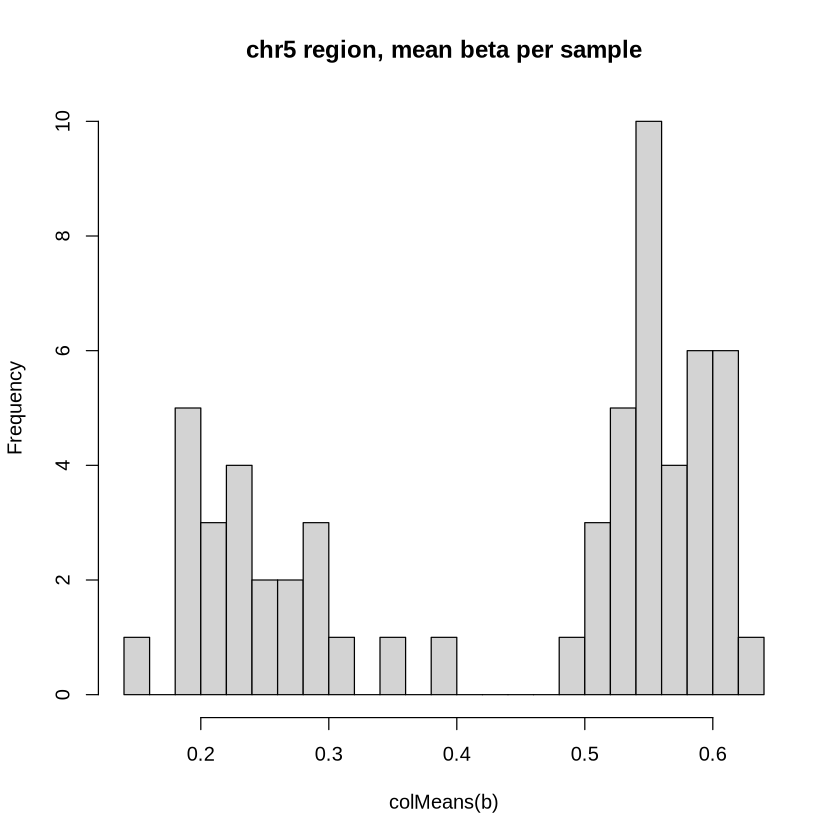

In [19]:
probes5 <- rownames(ann)[ann$chr=='chr5' & ann$pos>=135414858 & ann$pos<=135416613] #Checking regional distribution of differences 
probes5 <- intersect(probes5, rownames(m_ord))
b <- 2^m_ord[probes5,]/(1+2^m_ord[probes5,])
hist(colMeans(b), breaks=20, main='chr5 region, mean beta per sample')
table(colMeans(b) > 0.5, status_114134) #Checking to see if it correlates with allergy status

In [20]:
fisher.test(table(colMeans(b) > 0.5, status_114134)) #Chyecking if it correlates with allergy status


	Fisher's Exact Test for Count Data

data:  table(colMeans(b) > 0.5, status_114134)
p-value = 0.5852
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.4155345 5.2140362
sample estimates:
odds ratio 
  1.426364 


In [21]:
data.frame(probe = probes5,
           lfc = tt_114134[probes5,'logFC'],
           p = tt_114134[probes5,'P.Value'])[order(tt_114134[probes5,'P.Value']),][1:5,]

,probe,lfc,p
,<chr>,<dbl>,<dbl>
16,cg11978884,0.4887216,0.06141533
18,cg16684184,0.1724004,0.07514834
6,cg25340688,0.6142876,0.08404063
4,cg06536614,0.5505195,0.10482757
2,cg00124993,0.6579994,0.14392714


In [22]:
saveRDS(list(bumps_B50 = bumps$table, #Saving results
             nc886_probes = probes5,
             nc886_fisher = fisher.test(table(colMeans(b) > 0.5, status_114134)),
             nc886_modes = "bimodal, ~0.2 and ~0.55"),
        file.path(data_dir, 'dmr_results.rds'))

Reverse and Mirror Direction Probe Check (GSE118148-->GSE1124134)

In [28]:
top_b <- rownames(tt_189148)[order(tt_189148$P.Value)][1:100] #Taking first 100 most significant

comp <- data.frame(
  probe = top_b,
  lfc_adol   = tt_189148[top_b, 'logFC'],
  p_adol     = tt_189148[top_b, 'P.Value'],
  lfc_infant = tt_114134[top_b, 'logFC'],
  p_infant   = tt_114134[top_b, 'P.Value']
)

comp$concordant <- sign(comp$lfc_adol) == sign(comp$lfc_infant) #Checking to see if direction is shared

table(comp$concordant)
binom.test(sum(comp$concordant), 100, p = 0.5)


FALSE  TRUE 
   49    51 


	Exact binomial test

data:  sum(comp$concordant) and 100
number of successes = 51, number of trials = 100, p-value = 0.9204
alternative hypothesis: true probability of success is not equal to 0.5
95 percent confidence interval:
 0.4080363 0.6113558
sample estimates:
probability of success 
                  0.51 


In [29]:
top_a <- rownames(tt_114134)[order(tt_114134$P.Value)][1:100] #Other way (GSE114134-->GSE189148)

comp_a <- data.frame(
  probe = top_a,
  lfc_infant = tt_114134[top_a, 'logFC'],
  lfc_adol   = tt_189148[top_a, 'logFC'],
  p_adol     = tt_189148[top_a, 'P.Value']
)
comp_a$concordant <- sign(comp_a$lfc_infant) == sign(comp_a$lfc_adol)

table(comp_a$concordant)
binom.test(sum(comp_a$concordant), 100, p = 0.5)


FALSE  TRUE 
   33    67 


	Exact binomial test

data:  sum(comp_a$concordant) and 100
number of successes = 67, number of trials = 100, p-value = 0.0008737
alternative hypothesis: true probability of success is not equal to 0.5
95 percent confidence interval:
 0.5688272 0.7608015
sample estimates:
probability of success 
                  0.67 


In [31]:
#Permuation check on infant-->adolescent
set.seed(42)
perm_conc <- replicate(200, {
  y_shuf <- sample(status_114134)
  f <- eBayes(lmFit(m_ord, model.matrix(~ y_shuf)))
  t <- topTable(f, coef = 2, number = Inf, sort.by = 'none')
  tp <- rownames(t)[order(t$P.Value)][1:100]
  mean(sign(t[tp, 'logFC']) == sign(tt_189148[tp, 'logFC']))
})
mean(perm_conc); quantile(perm_conc, c(0.025, 0.975))

[1] 0.51155

2.5%   97.5% 
0.38975 0.62000

In [32]:
saveRDS(list(obs_infant_to_adol = 0.67, #Saving data
             obs_adol_to_infant = 0.51,
             binom_p = 0.00087,
             perm_null = perm_conc,
             perm_mean = mean(perm_conc),
             perm_ci = quantile(perm_conc, c(0.025, 0.975))),
        file.path(data_dir, 'directional_concordance.rds'))

Bumphunter on GSE118148

In [33]:
library(bumphunter)
library(doParallel)
registerDoParallel(cores = 4)

mVals_189148_shared <- readRDS(file.path(data_dir, 'mVals_189148_shared.rds'))

chr_b <- ann[rownames(mVals_189148_shared), 'chr']
pos_b <- ann[rownames(mVals_189148_shared), 'pos']
stopifnot(sum(is.na(chr_b)) == 0)

ord_b   <- order(chr_b, pos_b)
m_ord_b <- mVals_189148_shared[ord_b, ]
chr_ord_b <- chr_b[ord_b]
pos_ord_b <- pos_b[ord_b]

cluster_b <- clusterMaker(chr_ord_b, pos_ord_b, maxGap = 500)
length(unique(cluster_b))

[1] 381976

In [34]:
design_189148_bh <- model.matrix(~ status_189148 + factor(scan_dates))

set.seed(42)
t0 <- Sys.time()
bumps_b <- bumphunter(m_ord_b, design_189148_bh,
                      chr = chr_ord_b, pos = pos_ord_b,
                      cluster = cluster_b, coef = 2,
                      cutoff = 0.15, B = 250, type = "M")
Sys.time() - t0

saveRDS(bumps_b, file.path(data_dir, 'bumphunter_189148_B250.rds'))
dim(bumps_b$table)

[bumphunterEngine] The use of the permutation test is not recommended with multiple covariates, (ncol(design)>2). Consider changing 'nullMethod' changed to 'bootstrap' instead. See vignette for more information.

Warning message in bumphunterEngine(object, design = design, chr = chr, pos, cluster = cluster, :
“The use of the permutation test is not recommended with multiple covariates, (ncol(design)>2). Consider changing 'nullMethod' changed to 'bootstrap' instead. See vignette for more information.”
[bumphunterEngine] Parallelizing using 4 workers/cores (backend: doParallelMC, version: 1.0.17).

[bumphunterEngine] Computing coefficients.

[bumphunterEngine] Performing 250 permutations.

[bumphunterEngine] Computing marginal permutation p-values.

[bumphunterEngine] cutoff: 0.15

[bumphunterEngine] Finding regions.

[bumphunterEngine] Found 80793 bumps.

[bumphunterEngine] Computing regions for each permutation.

[bumphunterEngine] Estimating p-values and FWER.



Time difference of 3.440379 hours

[1] 80793    14

In [36]:
saveRDS(bumps_b, file.path(data_dir, 'bumphunter_189148_B250_SUSPECT.rds')) #Going to check dimensions, scan date, etc before confirming


In [37]:
dim(design_189148_bh)
head(design_189148_bh)
table(scan_dates)
length(scan_dates)
ncol(m_ord_b)

names(bumps_b)
class(bumps_b$table)
head(bumps_b$table[, 1:6], 3)

[1] 43  3

,(Intercept),status_189148control,factor(scan_dates)9/1/2020
1,1,0,1
2,1,0,1
3,1,0,0
4,1,0,0
5,1,0,0
6,1,0,0


scan_dates
8/28/2020  9/1/2020 
       34         9 

[1] 43

[1] 43

[1] "table"           "coef"            "fitted"          "pvaluesMarginal"
[5] "null"            "algorithm"

[1] "data.frame"

,chr,start,end,value,area,cluster
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
73854,chr5,135415190,135416613,-0.9733978,15.574365,299571
55835,chr12,10563981,10564015,-1.9064304,3.812861,79854
30529,chr22,48314374,48314942,1.5396563,4.618969,243377


In [38]:
nrow(bumps_b$table)
sum(bumps_b$table$fwer < 0.05, na.rm = TRUE)

[1] 80793

[1] 0

In [39]:
colnames(design_114134)

[1] "(Intercept)"          "status_114134control"

In [40]:
subset(bumps_b$table, chr == 'chr1' & start < 950000 & end > 948000)[,
       c('chr','start','end','value','L','p.value','fwer')]

,chr,start,end,value,L,p.value,fwer
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
49143,chr1,948625,948627,-0.3722121,2,0.005893089,1
24,chr1,948814,948814,0.1734976,1,0.731086019,1


In [41]:
saveRDS(bumps_b, file.path(data_dir, 'bumphunter_189148_B250.rds')) #Saving in original name, all good